# Language Model Information Retrieval (LMIR)

Instead of scoring documents by *how often* query words appear, LMIR asks: **how likely is this document to have generated this query?**

Each document is treated as a small language model — a probability distribution over words. Ranking by this probability naturally surfaces documents that *talk like* the query.

**The smoothing problem:** A word that doesn't appear in a document at all would give a probability of 0, killing the whole score via the log-sum. We fix this with **Jelinek-Mercer (JM) smoothing**, which blends the document's own distribution with the corpus-wide distribution:

$$P(t \mid d) = (1 - \lambda) \cdot \frac{tf(t,d)}{|d|} + \lambda \cdot \frac{cf(t)}{|C|}$$

where λ controls the blend: **low λ = trust the document**, **high λ = trust the collection**.

| Step | What we do |
|------|------------|
| 1 | Load the dataset |
| 2 | Visualise the corpus |
| 3 | Build collection statistics |
| 4 | Implement LMIR with JM smoothing |
| 5 | Evaluate at λ = 0.4 |
| 6 | Sweep λ to find the optimal value |

## The Dataset: SciFact

Same benchmark as the other notebooks — see `01_TF-IDFvsBM25.ipynb` for details.

## Step 1: Load the Data

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import load_dataset, tokenize_dataset

corpus, queries, qrels_train, qrels_test, qrels_all = load_dataset()

--- Dataset Statistics ---
Total documents in corpus       : 5183
Total queries                   : 1109
Queries with TRAIN answer keys  : 809
Queries with TEST  answer keys  : 300
Total queries with answer keys  : 1109


In [2]:
relevant   = sum(sum(1 for s in docs.values() if s > 0) for docs in qrels_all.values())
irrelevant = sum(sum(1 for s in docs.values() if s == 0) for docs in qrels_all.values())
print(f'Relevant query-document pairs  : {relevant}')
print(f'Irrelevant query-document pairs: {irrelevant}')

Relevant query-document pairs  : 1258
Irrelevant query-document pairs: 0


## Step 2: Dataset Visualisation

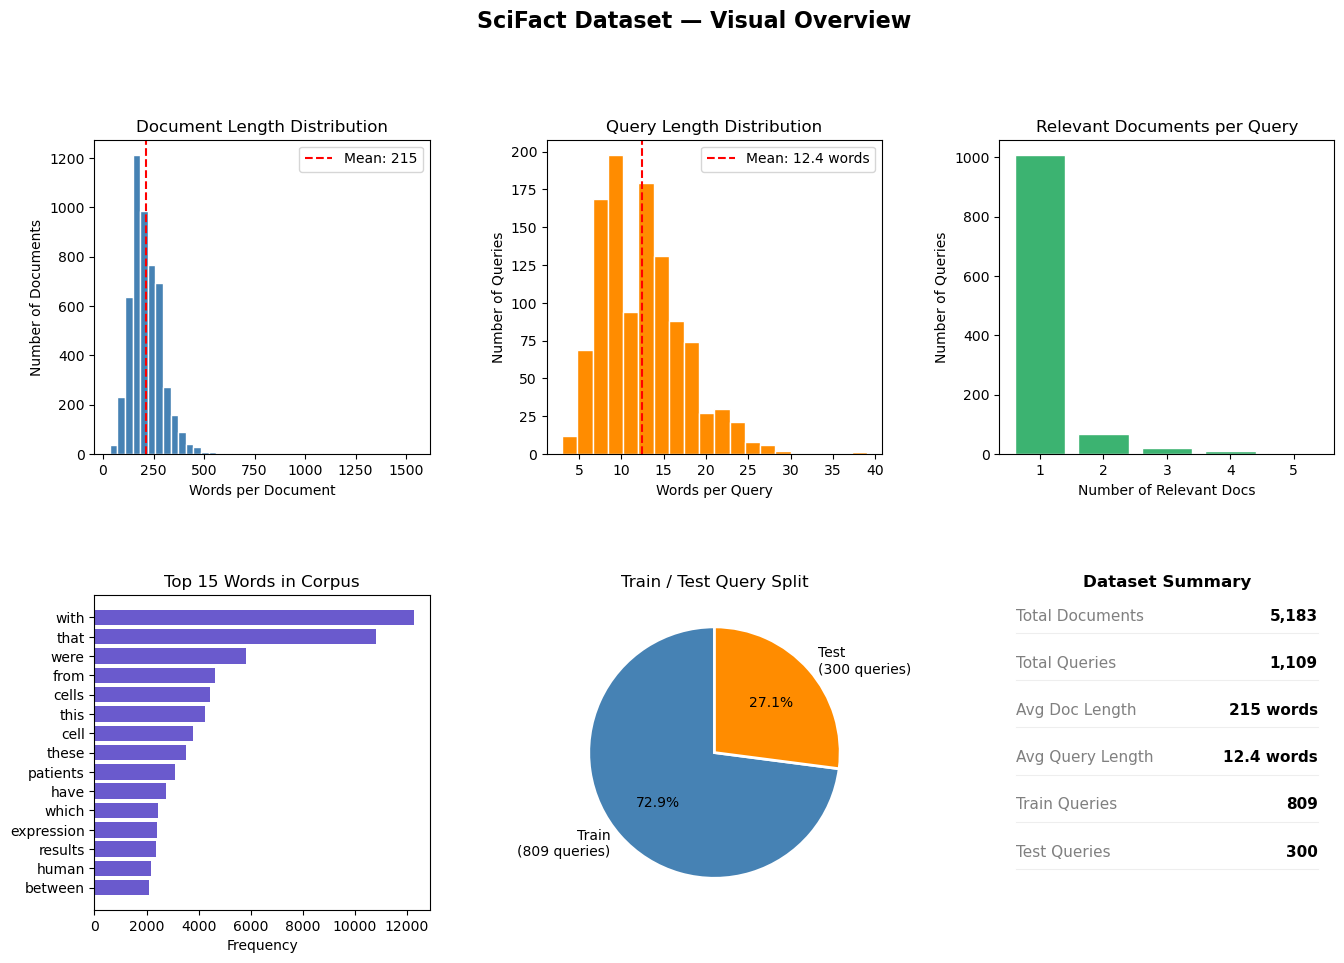

Dataset visualization complete.


In [3]:
from src.visualization import plot_dataset_overview

plot_dataset_overview(corpus, queries, qrels_train, qrels_test, qrels_all)

## Step 3: Preprocessing & Collection Statistics

In [4]:
tokenized_corpus, tokenized_queries = tokenize_dataset(corpus, queries)

sample_id = list(queries.keys())[0]
print("Original :", queries[sample_id])
print("Tokenised:", tokenized_queries[sample_id])

Original : 0-dimensional biomaterials lack inductive properties.
Tokenised: ['0dimensional', 'biomaterials', 'lack', 'inductive', 'properties']


In [5]:
from collections import Counter

# Per-document statistics
document_term_frequencies = {}   # tf(term, doc)
document_lengths          = {}   # |d|

# Corpus-wide statistics
collection_frequencies = Counter()  # cf(term)
collection_length      = 0          # |C|

for doc_id, tokens in tokenized_corpus.items():
    term_freqs = Counter(tokens)
    document_term_frequencies[doc_id] = term_freqs
    document_lengths[doc_id]          = len(tokens)
    collection_frequencies.update(tokens)
    collection_length                 += len(tokens)

print(f"Documents       : {len(document_term_frequencies)}")
print(f"Collection size : {collection_length:,} tokens")
print(f"Vocabulary size : {len(collection_frequencies):,} unique terms")

Documents       : 5183
Collection size : 1,106,819 tokens
Vocabulary size : 50,676 unique terms


## Step 4: LMIR with Jelinek-Mercer Smoothing

$$\log P(q \mid d) = \sum_{t \in q} \log \left[ (1-\lambda) \cdot \frac{tf(t,d)}{|d|} + \lambda \cdot \frac{cf(t)}{|C|} \right]$$

Terms with probability 0 are silently skipped (they contribute $-\infty$ in log space and are undefined).

In [6]:
import math

def lmir_jm_score(query_tokens, doc_id, lambda_param=0.4):
    """Compute the log-probability of query given document under JM smoothing."""
    score   = 0.0
    doc_tf  = document_term_frequencies[doc_id]
    doc_len = document_lengths[doc_id]

    for term in query_tokens:
        tf              = doc_tf.get(term, 0)
        collection_prob = collection_frequencies.get(term, 0) / collection_length
        term_prob       = (1 - lambda_param) * (tf / doc_len) + lambda_param * collection_prob

        if term_prob > 0:
            score += math.log(term_prob)

    return score


def retrieve_lmir_jm(tokenized_queries, corpus_ids, top_k=10, lambda_param=0.4):
    """Rank all corpus documents for every query using LMIR-JM."""
    rankings = {}
    for query_id, query_tokens in tokenized_queries.items():
        scores = [(doc_id, lmir_jm_score(query_tokens, doc_id, lambda_param))
                  for doc_id in corpus_ids]
        scores.sort(key=lambda x: x[1], reverse=True)
        rankings[query_id] = scores[:top_k]
    return rankings

In [7]:
corpus_ids = list(tokenized_corpus.keys())

# Verification: top-10 docs for the first query at lambda=0.4
test_rankings = retrieve_lmir_jm(
    {list(tokenized_queries.keys())[0]: list(tokenized_queries.values())[0]},
    corpus_ids, top_k=10, lambda_param=0.4
)
sample_id = list(test_rankings.keys())[0]
print(f"Query: {queries[sample_id]}\n")
for doc_id, score in test_rankings[sample_id]:
    label = '✅' if qrels_all.get(sample_id, {}).get(doc_id, 0) > 0 else '❌'
    print(f"  {label}  {score:.4f}  {corpus[doc_id].get('title', '')[:70]}")

Query: 0-dimensional biomaterials lack inductive properties.

  ❌  -38.8798  Potent, Selective, and Orally Bioavailable Inhibitors of VPS34 Provide
  ❌  -39.0211  In situ regulation of DC subsets and T cells mediates tumor regression
  ❌  -39.0567  Metastatic colonization requires the repression of the epithelial-mese
  ❌  -39.1438  Extracellular vesicles for drug delivery.
  ❌  -39.5516  Geometry, epistasis, and developmental patterning.
  ❌  -39.6986  Interleukin 6 plays a key role in the development of antigen-induced a
  ❌  -39.8260  Biological properties of herpes simplex virus 2 replication-defective 
  ❌  -40.0263  Aptamer-functionalized lipid nanoparticles targeting osteoblasts as a 
  ❌  -40.1731  ALDH1 is a marker of normal and malignant human mammary stem cells and
  ❌  -40.4101  A core subunit of Polycomb repressive complex 1 is broadly conserved i


## Step 5: Evaluation at λ = 0.4

In [8]:
from src.evaluation import evaluate_rankings, print_results

print("Running LMIR at λ=0.4 (this may take a few minutes)...")
rankings_04 = retrieve_lmir_jm(tokenized_queries, corpus_ids, top_k=10, lambda_param=0.4)

p, r, n = evaluate_rankings(rankings_04, qrels_all, k=10)
print_results({'LMIR (λ=0.4)': (p, r, n)})

Running LMIR at λ=0.4 (this may take a few minutes)...
Model                P@10        R@10     NDCG@10
-------------------------------------------------
LMIR (λ=0.4)       0.0825      0.7371      0.6214


## Step 6: λ Sweep — Finding the Optimal Smoothing Weight

In [9]:
lambda_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results = []

for lam in lambda_values:
    print(f"  Evaluating λ = {lam}")
    rankings = retrieve_lmir_jm(tokenized_queries, corpus_ids, top_k=10, lambda_param=lam)
    p, r, n  = evaluate_rankings(rankings, qrels_all, k=10)
    results.append((lam, p, r, n))

  Evaluating λ = 0.05
  Evaluating λ = 0.1
  Evaluating λ = 0.15
  Evaluating λ = 0.2
  Evaluating λ = 0.25
  Evaluating λ = 0.3
  Evaluating λ = 0.35
  Evaluating λ = 0.4
  Evaluating λ = 0.45
  Evaluating λ = 0.5


In [10]:
print("\nλ Sweep Results")
print("-" * 55)
best_lam, best_ndcg = results[0][0], results[0][3]
for lam, p, r, n in results:
    print(f"  λ={lam:<5}  P@10={p:.4f}  R@10={r:.4f}  NDCG@10={n:.4f}")
    if n > best_ndcg:
        best_lam, best_ndcg = lam, n
print(f"\n🏆 Best λ = {best_lam}  |  NDCG@10 = {best_ndcg:.4f}")


λ Sweep Results
-------------------------------------------------------
  λ=0.05   P@10=0.0782  R@10=0.7003  NDCG@10=0.5906
  λ=0.1    P@10=0.0793  R@10=0.7100  NDCG@10=0.5977
  λ=0.15   P@10=0.0800  R@10=0.7159  NDCG@10=0.6032
  λ=0.2    P@10=0.0806  R@10=0.7206  NDCG@10=0.6086
  λ=0.25   P@10=0.0811  R@10=0.7251  NDCG@10=0.6116
  λ=0.3    P@10=0.0816  R@10=0.7296  NDCG@10=0.6158
  λ=0.35   P@10=0.0822  R@10=0.7350  NDCG@10=0.6195
  λ=0.4    P@10=0.0825  R@10=0.7371  NDCG@10=0.6214
  λ=0.45   P@10=0.0828  R@10=0.7398  NDCG@10=0.6236
  λ=0.5    P@10=0.0830  R@10=0.7416  NDCG@10=0.6272

🏆 Best λ = 0.5  |  NDCG@10 = 0.6272


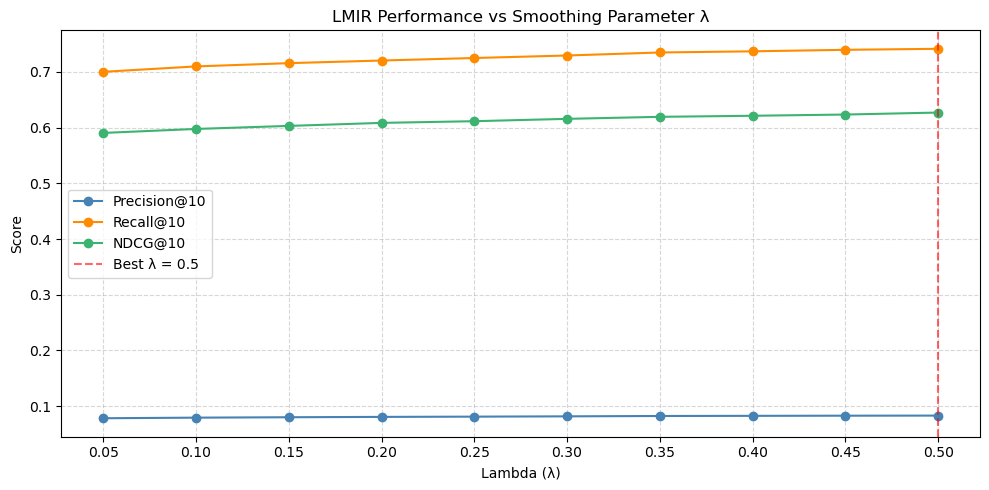

In [11]:
import matplotlib.pyplot as plt

lambdas    = [r[0] for r in results]
precisions = [r[1] for r in results]
recalls    = [r[2] for r in results]
ndcgs      = [r[3] for r in results]

plt.figure(figsize=(10, 5))
plt.plot(lambdas, precisions, marker='o', label='Precision@10', color='steelblue')
plt.plot(lambdas, recalls,    marker='o', label='Recall@10',    color='darkorange')
plt.plot(lambdas, ndcgs,      marker='o', label='NDCG@10',      color='mediumseagreen')

best = max(results, key=lambda x: x[3])
plt.axvline(x=best[0], color='red', linestyle='--', alpha=0.6, label=f'Best λ = {best[0]}')

plt.xlabel('Lambda (λ)')
plt.ylabel('Score')
plt.title('LMIR Performance vs Smoothing Parameter λ')
plt.xticks(lambdas)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

### Interpretation

- **Low λ** → model trusts the document's own vocabulary. Good when queries and docs share precise terms. Risk: zero-probability terms kill the score.
- **High λ** → model trusts the collection. Robust to unseen terms, but loses document specificity.
- **Optimal λ** is somewhere in between, where both signals complement each other.